# Train a Custom YOLO Model — Rename or Merge Labels


This notebook is designed to help you train your own YOLO models from scratch or fine-tune existing ones.  
You can use either:

- **Local datasets** (e.g., in YOLO format stored on your Google Drive or GitHub)
- **Datasets from Roboflow**, which can be easily imported via a download link
- **Example dataset**, from a linked github repository

The workflow includes:
- Loading and organizing your dataset
- Writing a custom `.yaml` config file
- Launching training with the `ultralytics` YOLO implementation
- (Optional) Exporting and evaluating your trained model

This is ideal for training models on custom objects — whether you're working with animals, vehicles, tools, or underwater footage.

---

Make sure your dataset is in the correct YOLO structure:

```
dataset/
├── train/
│   ├── images/
│   └── labels/
├── valid/
│   ├── images/
│   └── labels/
├── test/   # optional
│   ├── images/
│   └── labels/
└── data.yaml
```

# Import libraries

In [5]:
import glob
import os
import random
import shutil
import sys
import time
from pathlib import Path

from google.colab import drive, runtime
from IPython.display import Image, display


In [6]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [7]:
# Run this before importing NumPy, SciPy, Ultralytics, or dataset-fixer.
%pip install --upgrade ultralytics
%pip install "dataset-fixer @ git+https://github.com/mooch443/dataset-fixer.git"

import ultralytics
ultralytics.checks()

from ultralytics import YOLO
from dataset_fixer import Dataset as FixedDataset
import numpy as np


Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 21.0/225.8 GB disk)


In [8]:
# The dataset selector loads its helper directly and is safe to run independently.
print('Dataset helper will be loaded by the selector cell.')


Dataset helper will be loaded by the selector cell.


### 🔗 Connect to Your Google Drive

Google Colab is a cloud-based Python environment that lets you run code in your browser, with free access to GPUs.  

To access your datasets or save model outputs, you’ll need to connect Colab to your Google Drive.
This allows you to read and write files directly from your Drive, making it easier to store large datasets or export trained models.

Run the cell below to authorize access.

In [9]:
# Mount google drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# Load data

Use the selector below to load a dataset from a Roboflow snippet, a shared
Google Drive ZIP, the Hexbugs example, or the **multilabel relabeling example**.

The multilabel example comes from
`TRex-tutorials-data/YOLO-models/multilabel-example` and is intended for trying
the rename, merge, and drop controls in this notebook.


In [10]:
import importlib.util
import inspect
import subprocess
import sys
from pathlib import Path

def selector_is_current(module):
    return 'include_multilabel_example' in inspect.signature(module.launch_dataset_selector).parameters

# Load the helper file directly. This avoids requiring `utils` to be an
# importable package and makes this cell independent of earlier setup cells.
candidate_files = [
    Path.cwd() / 'utils' / 'datasets.py',
    Path('/content/train-custom-YOLO-Colab/utils/datasets.py'),
]
candidate_files.extend(
    parent / 'train-custom-YOLO-Colab' / 'utils' / 'datasets.py'
    for parent in Path.cwd().parents
)

available_helpers = [
    path.resolve()
    for path in dict.fromkeys(candidate_files)
    if path.is_file()
]
if not available_helpers:
    repository_root = Path('/content/train-custom-YOLO-Colab')
    subprocess.run([
        'git', 'clone',
        'https://github.com/albiangela/train-custom-YOLO-Colab.git',
        str(repository_root),
    ], check=True)
    available_helpers = [repository_root / 'utils' / 'datasets.py']

datasets_module = None
for helper_path in available_helpers:
    spec = importlib.util.spec_from_file_location('_current_yolo_datasets', helper_path)
    candidate_module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = candidate_module
    spec.loader.exec_module(candidate_module)
    if datasets_module is None or selector_is_current(candidate_module):
        datasets_module = candidate_module
    if selector_is_current(candidate_module):
        break

workspace_dataset_root = Path('/content/datasets')
print('Dataset selector loaded from:', datasets_module.__file__)

if selector_is_current(datasets_module):
    datasets_module.launch_dataset_selector(
        globals(),
        dataset_root=workspace_dataset_root,
        include_multilabel_example=True,
    )
else:
    # Backward-compatible unified selector for older Colab checkouts.
    import ipywidgets as widgets
    from IPython.display import display

    style = {'description_width': '120px'}
    source_dropdown = widgets.Dropdown(
        options=[
            ('Roboflow snippet', 'roboflow'),
            ('Google Drive link', 'drive'),
            ('Example dataset (Hexbugs)', 'hexbugs'),
            ('Multiabel example', 'multilabel'),
        ],
        value='roboflow',
        description='Source:',
        style=style,
    )
    roboflow_input = widgets.Textarea(
        description='Snippet:',
        placeholder='Paste the full Roboflow download snippet here…',
        layout=widgets.Layout(width='100%', height='180px'),
        style=style,
    )
    drive_input = widgets.Text(
        description='Drive link:',
        placeholder='https://drive.google.com/file/d/…',
        layout=widgets.Layout(width='100%'),
        style=style,
    )
    drive_name = widgets.Text(
        description='Dataset name:',
        placeholder='Optional folder name',
        layout=widgets.Layout(width='100%'),
        style=style,
    )
    example_help = widgets.HTML()
    download_button = widgets.Button(
        description='Download dataset',
        button_style='primary',
        icon='download',
    )
    selector_status = widgets.Output()

    roboflow_box = widgets.VBox([roboflow_input])
    drive_box = widgets.VBox([drive_input, drive_name])
    forms = {
        'roboflow': roboflow_box,
        'drive': drive_box,
        'hexbugs': example_help,
        'multilabel': example_help,
    }

    def show_selected_form(kind):
        roboflow_box.layout.display = 'flex' if kind == 'roboflow' else 'none'
        drive_box.layout.display = 'flex' if kind == 'drive' else 'none'
        example_help.layout.display = 'block' if kind in {'hexbugs', 'multilabel'} else 'none'
        if kind == 'hexbugs':
            example_help.value = '<small>Downloads the Hexbugs example from TRex-tutorials-data.</small>'
        elif kind == 'multilabel':
            example_help.value = '<small>Downloads YOLO-models/multilabel-example.</small>'

    def source_changed(change):
        show_selected_form(change['new'])
        with selector_status:
            selector_status.clear_output()

    def download_selected_dataset(_button):
        with selector_status:
            selector_status.clear_output()
            download_button.disabled = True
            try:
                choice = source_dropdown.value
                if choice == 'roboflow':
                    snippet = roboflow_input.value.strip()
                    if not snippet:
                        raise ValueError('Paste the Roboflow snippet first.')
                    source = datasets_module.RoboflowSource(
                        **datasets_module._parse_roboflow_snippet(snippet)
                    )
                elif choice == 'drive':
                    file_id = datasets_module._extract_drive_file_id(drive_input.value.strip())
                    if not file_id:
                        raise ValueError('Provide a valid Google Drive link or file ID.')
                    source = datasets_module.DriveSource(
                        file_id=file_id,
                        name_hint=drive_name.value.strip() or None,
                    )
                else:
                    datasets_module._EXAMPLE_SUBDIR = Path(
                        'YOLO-models/multilabel-example'
                        if choice == 'multilabel'
                        else 'YOLO-models/hexbugs-annotation-dataset'
                    )
                    source = datasets_module.ExampleSource()

                dataset_path = datasets_module.fetch_dataset(
                    source,
                    dataset_root=workspace_dataset_root,
                )
                globals()['dataset_path'] = dataset_path
                globals()['name'] = dataset_path.name
                globals()['DATASET_SOURCE'] = source
                globals()['DATASET_ROOT'] = workspace_dataset_root
                print(f'✅ Dataset ready at: {dataset_path}')
                print(f"   Variable `name` set to '{dataset_path.name}'.")
            except Exception as exc:
                print(f'⚠️ {exc}')
            finally:
                download_button.disabled = False

    source_dropdown.observe(source_changed, names='value')
    download_button.on_click(download_selected_dataset)
    show_selected_form(source_dropdown.value)
    display(widgets.VBox([
        source_dropdown,
        roboflow_box,
        drive_box,
        example_help,
        download_button,
        selector_status,
    ]))


Dataset selector loaded from: /content/train-custom-YOLO-Colab/utils/datasets.py


# Choose label names

The window reads the original class IDs and names from `data.yaml`. Edit the
target name to rename a class. Give several classes the same target name to
merge them. Uncheck **Keep** to remove a class. Click **Apply mapping** before
running the preparation cell.

`dataset-fixer` validates the source, applies the mapping, creates a
reproducible split, and writes matching labels and `data.yaml` metadata. The
original dataset is never edited.


In [11]:
import yaml
from types import SimpleNamespace

dataset = SimpleNamespace(location='/content/datasets/', name=name, version=1)
dataset_root = os.path.join(dataset.location, name)
source_yaml = os.path.join(dataset_root, 'data.yaml')
out_dir = dataset_root + '-dataset-fixed'

assert os.path.isdir(os.path.join(dataset_root, 'train')), dataset_root
assert os.path.isfile(source_yaml), source_yaml

# Build a portable compatibility YAML without modifying the downloaded source.
# This also repairs Roboflow exports that contain paths such as ../train/images.
with open(source_yaml, 'r') as stream:
    fixer_yaml_data = yaml.safe_load(stream) or {}
fixer_yaml_data['path'] = os.path.abspath(dataset_root)
for split_key in ('train', 'val', 'valid', 'validation', 'test'):
    fixer_yaml_data.pop(split_key, None)
for yaml_key, folder_candidates in {
    'train': ('train',),
    'val': ('val', 'valid', 'validation'),
    'test': ('test',),
}.items():
    for folder_name in folder_candidates:
        if os.path.isdir(os.path.join(dataset_root, folder_name, 'images')):
            fixer_yaml_data[yaml_key] = f'{folder_name}/images'
            break

fixer_source_yaml = dataset_root + '-dataset-fixer-input.yaml'
with open(fixer_source_yaml, 'w') as stream:
    yaml.safe_dump(fixer_yaml_data, stream, sort_keys=False, allow_unicode=True)

print('Dataset:', dataset_root)
print('dataset-fixer input:', fixer_source_yaml)
print('Fixed output:', out_dir)


Dataset: /content/datasets/example_dataset
dataset-fixer input: /content/datasets/example_dataset-dataset-fixer-input.yaml
Fixed output: /content/datasets/example_dataset-dataset-fixed


In [12]:
import ipywidgets as widgets
import yaml

with open(source_yaml, 'r') as stream:
    yaml_data = yaml.safe_load(stream) or {}

raw_names = yaml_data.get('names')
if isinstance(raw_names, dict):
    original_names = [str(raw_names.get(i, raw_names.get(str(i), f'class_{i}')))
                      for i in range(max(map(int, raw_names.keys())) + 1)]
elif isinstance(raw_names, list):
    original_names = [str(name) for name in raw_names]
else:
    raise ValueError(f"No valid 'names' list or dictionary in {source_yaml}")

mapping_rows = []
for class_id, class_name in enumerate(original_names):
    keep = widgets.Checkbox(value=True, description='Keep', indent=False, layout=widgets.Layout(width='75px'))
    target = widgets.Text(value=class_name, description=f'{class_id}: {class_name} →',
                          style={'description_width': 'initial'}, layout=widgets.Layout(width='520px'))
    mapping_rows.append((class_id, keep, target))

status = widgets.HTML('<i>Edit the mapping, then click Apply mapping.</i>')
apply_button = widgets.Button(description='Apply mapping', button_style='success', icon='check')

def apply_label_mapping(_):
    global allowed_ids, collapse_map, new_class_ids
    selected = [(class_id, target.value.strip()) for class_id, keep, target in mapping_rows if keep.value]
    if not selected:
        status.value = '<b style="color:#b00">Keep at least one class.</b>'
        return
    if any(not target_name for _, target_name in selected):
        status.value = '<b style="color:#b00">Target names cannot be empty.</b>'
        return

    ordered_targets = list(dict.fromkeys(target_name for _, target_name in selected))
    new_class_ids = {target_name: new_id for new_id, target_name in enumerate(ordered_targets)}
    collapse_map = {class_id: target_name for class_id, target_name in selected}
    allowed_ids = set(collapse_map)
    status.value = '<b style="color:#080">Mapping ready:</b> ' + ', '.join(
        f'{name}={class_id}' for name, class_id in new_class_ids.items()
    )

apply_button.on_click(apply_label_mapping)
display(widgets.VBox([
    widgets.HTML('<b>Original class → target class</b>'),
    *[widgets.HBox([keep, target]) for _, keep, target in mapping_rows],
    apply_button,
    status,
]))


Loading YOLO dataset:   0%|          | 0/6 [00:00<?, ?image/s]

Validating dataset:   0%|          | 0/6 [00:00<?, ?image/s]

Dataset 'example_dataset__rename-source_class_0-source_class_1-source_class_2__8ad74a4c__remove-source_class_2-source_class_5__eb2ecd7f__rename-bogong__8efa1b1d__rename-coleoptera__267cb646__rename-moth_na__77772153__rename-objects__d66d72d4__split-train70-val20-test10__669f37e6' [detect; virtual pipeline; yolo]
  images: 6 | annotations: 215 | empty: 0 (0.0%)
  classes: 4 | splits: 3
  image size: 2160x2160
  location: /content/datasets/example_dataset

  Split statistics
    split  images  annotated  empty  annotations
    -----  ------  ---------  -----  -----------
    train       4          4      0          144
    val         1          1      0           13
    test        1          1      0           58
    total       6          6      0          215

  Class statistics (annotation instances and images containing class)
    id  name        annotations  images  image %
    --  ----------  -----------  ------  -------
     0  bogong               45       6   100.0%
     1  co

Renaming classes:   0%|          | 0/6 [00:00<?, ?image/s]

/usr/local/lib/python3.12/dist-packages/dataset_fixer/dataset_comparison.py:311: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rows = pd.concat(


...


Created step-007-split
Location: /content/datasets/.example_dataset-dataset-fixed.pipeline-2x2c1koi/step-007-split
data.yaml: /content/datasets/.example_dataset-dataset-fixed.pipeline-2x2c1koi/step-007-split/data.yaml
Settings fingerprint: 4a323bdd
Duration: 23.22s | throughput: 0.26 images/s | images: 6 | annotations: 215 | training_ready: True
Visual audits: ['reports/plots.png']
Reports: /content/datasets/.example_dataset-dataset-fixed.pipeline-2x2c1koi/step-007-split/reports

export: example_dataset__rename-source_class_0-source_class_1-source_class_2__8ad74a4c__remove-source_class_2-source_class_5__eb2ecd7f__rename-bogong__8efa1b1d__rename-coleoptera__267cb646__rename-moth_na__77772153__rename-objects__d66d72d4__split-train70-val20-test10__669f37e6
Destination: /content/datasets/example_dataset-dataset-fixed
Images: 6 | splits: ['test', 'train', 'val']
Settings: {"allow_lossy": false, "splits": ["test", "train", "val"], "visualize": true, "visualize_kwargs": {}}
Validation: sourc

Exporting YOLO dataset:   0%|          | 0/6 [00:00<?, ?image/s]

Validating complete staged output before atomic publication (streaming, bounded memory)...


Streaming staged validation:   0%|          | 0/6 [00:00<?, ?image/s]

Reusing validated in-memory index; published dataset is not rescanned.

Created example_dataset__rename-source_class_0-source_class_1-source_class_2__8ad74a4c__remove-source_class_2-source_class_5__eb2ecd7f__rename-bogong__8efa1b1d__rename-coleoptera__267cb646__rename-moth_na__77772153__rename-objects__d66d72d4__split-train70-val20-test10__669f37e6
Location: /content/datasets/example_dataset-dataset-fixed
data.yaml: /content/datasets/example_dataset-dataset-fixed/data.yaml
Settings fingerprint: c26f19b2
Duration: 20.84s | throughput: 0.29 images/s | images: 6 | annotations: 215 | training_ready: True
Visual audits: ['reports/plots.png']
Reports: /content/datasets/example_dataset-dataset-fixed/reports


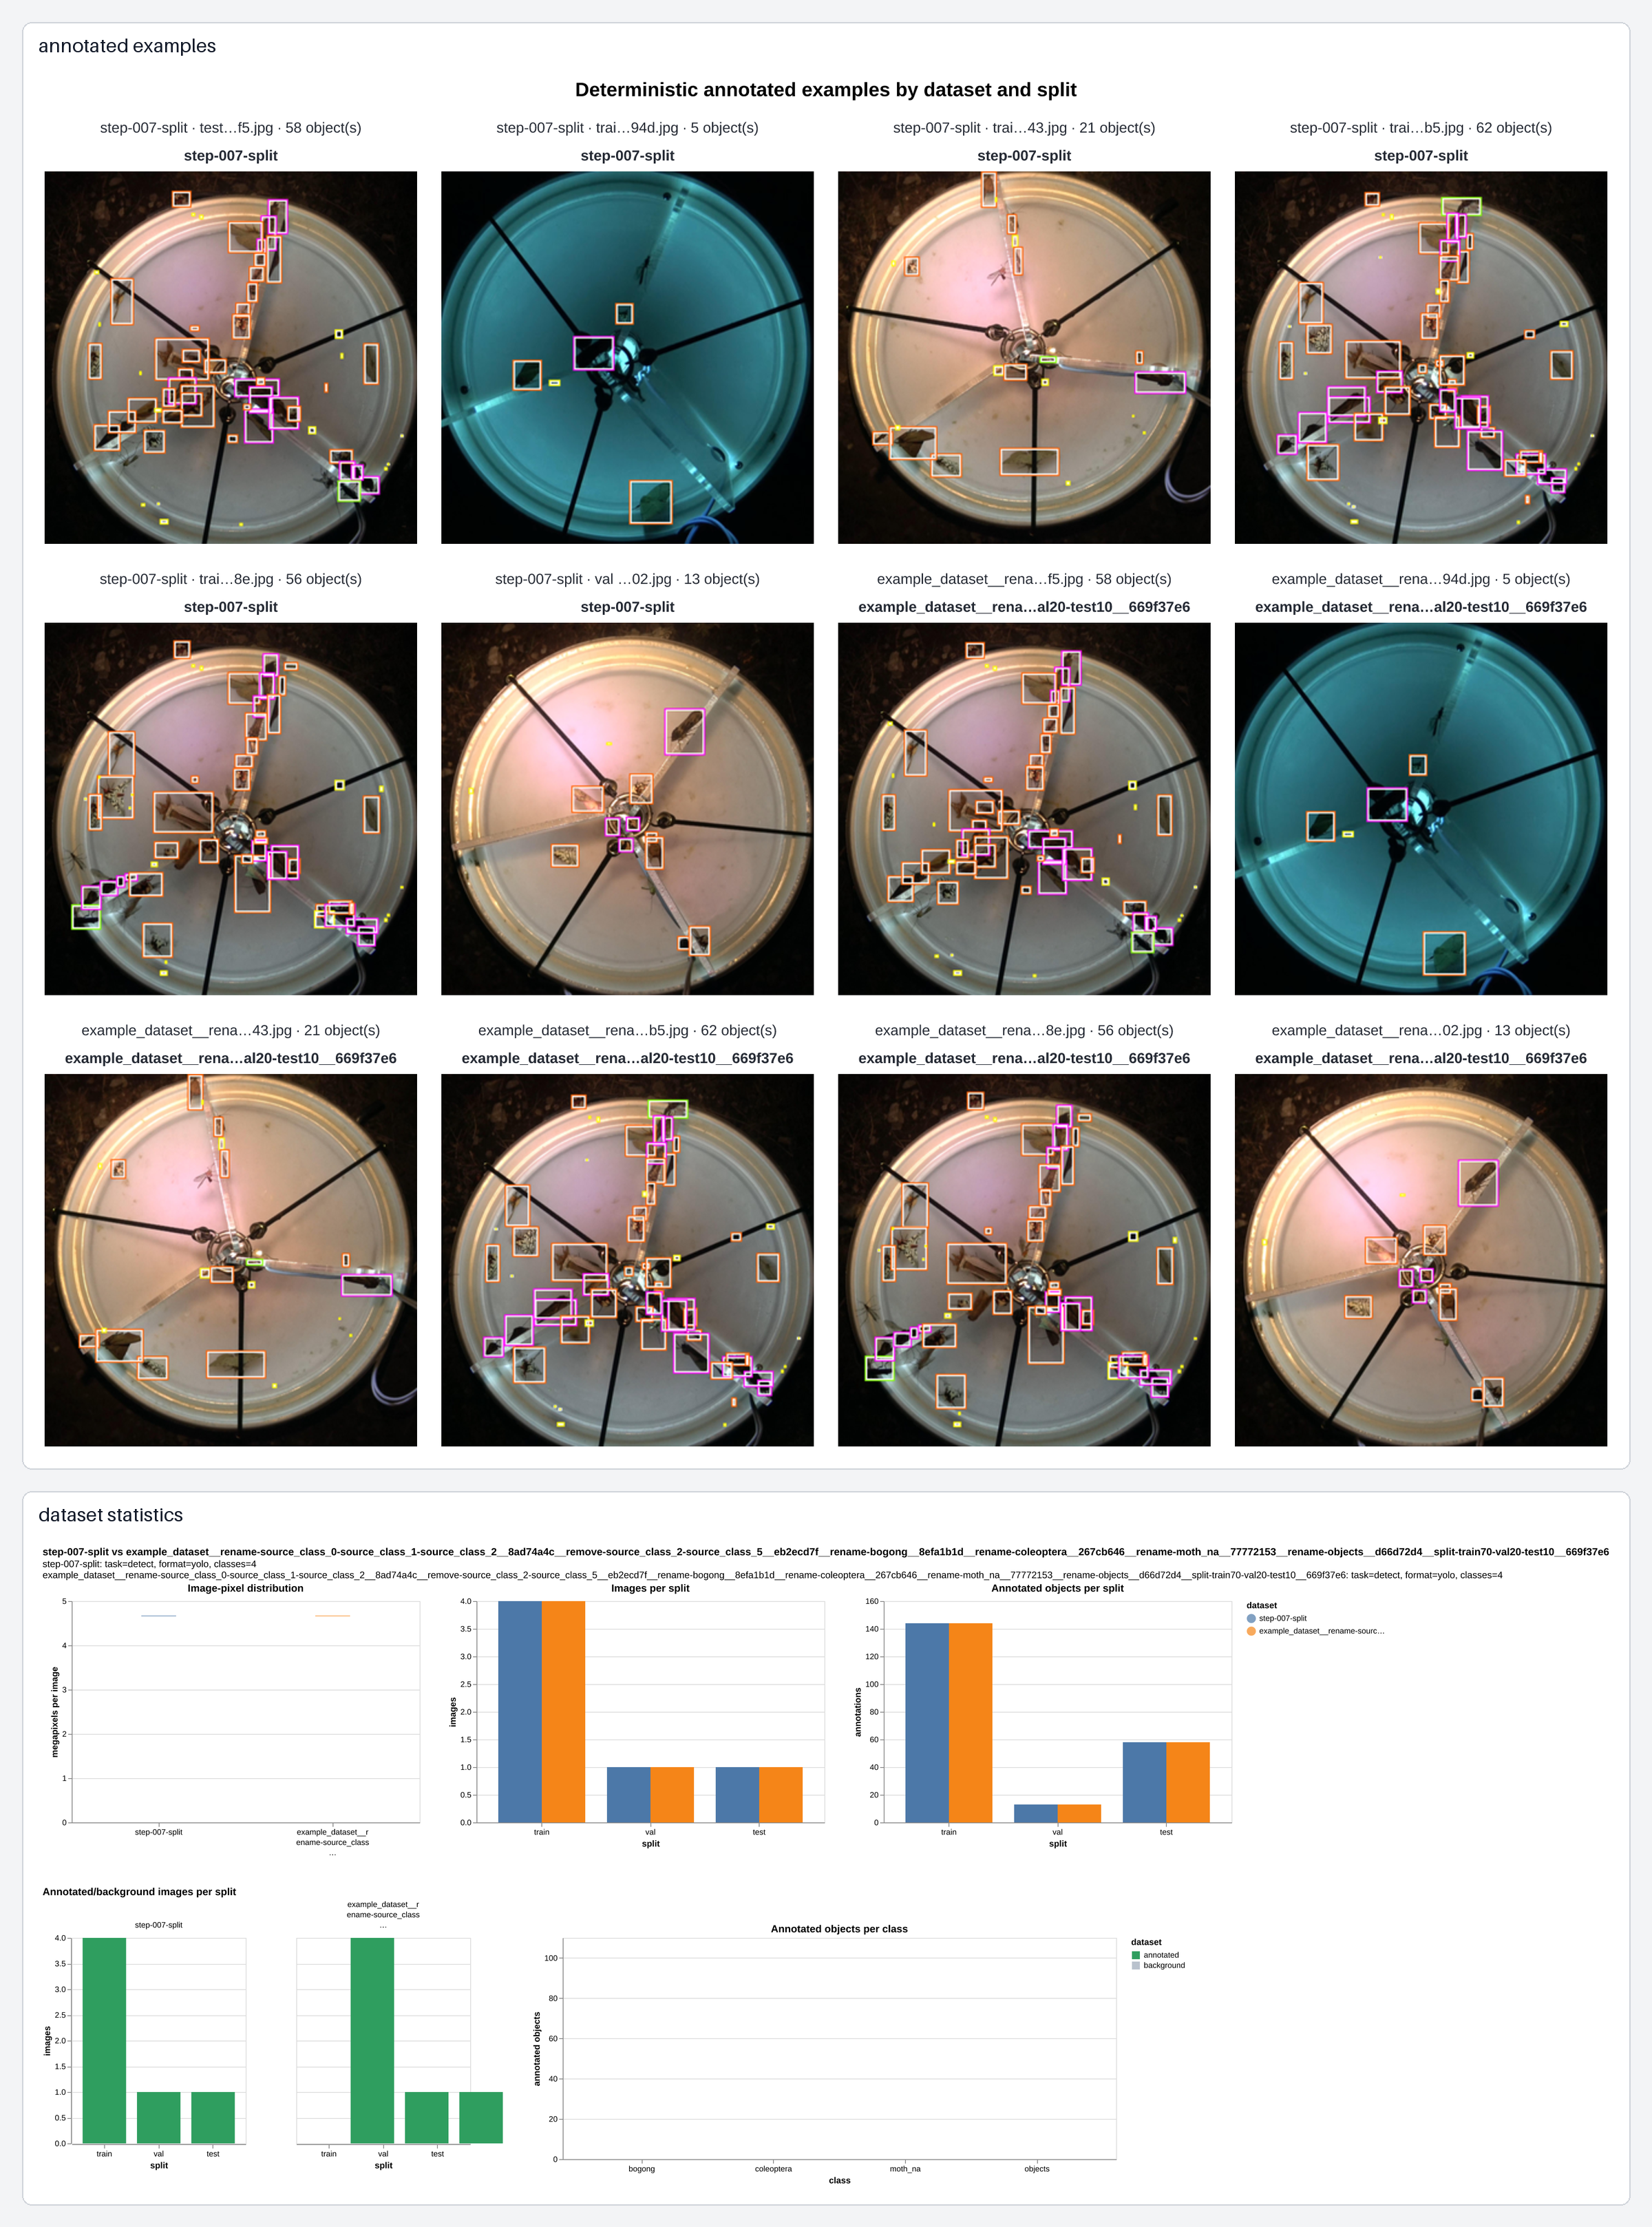

data.yaml: /content/datasets/example_dataset-dataset-fixed/data.yaml
ZIP written to: /content/datasets/example_dataset-dataset-fixed.zip


In [13]:

assert 'collapse_map' in globals(), 'Click Apply mapping in the previous cell first.'

fixed_dataset = FixedDataset.open(
    fixer_source_yaml,
    errors='skip',
    progress=True,
)
def apply_mapping_with_dataset_fixer(fixed_dataset):
    # Temporary unique names make arbitrary rename/merge combinations safe,
    # even when a requested target is also an existing source class name.
    temporary_names = {class_id: f'__source_class_{class_id}__' for class_id in range(len(original_names))}
    plan = fixed_dataset.rename_classes({
        original_names[class_id]: temporary_name
        for class_id, temporary_name in temporary_names.items()
    })

    dropped = [temporary_names[class_id] for class_id in range(len(original_names)) if class_id not in allowed_ids]
    if dropped:
        plan = plan.remove_classes(dropped, visualize=False)

    for target_name in new_class_ids:
        source_ids = [class_id for class_id, mapped_name in collapse_map.items() if mapped_name == target_name]
        source_names = [temporary_names[class_id] for class_id in source_ids]
        anchor, *merged_sources = source_names
        if merged_sources:
            plan = plan.remove_classes(merged_sources, merge_into=anchor, visualize=False)
        plan = plan.rename_classes({anchor: target_name})
    return plan

relabelled_plan = apply_mapping_with_dataset_fixer(fixed_dataset)
split_plan = relabelled_plan.split(
    {'train': 0.7, 'val': 0.2, 'test': 0.1},
    seed=42,
    visualize=True,
    progress=True,
)

overwrite_output = False
if os.path.exists(out_dir):
    if overwrite_output:
        shutil.rmtree(out_dir)
    else:
        raise FileExistsError(
            f'{out_dir} already exists. Delete it or set overwrite_output=True before rerunning.'
        )

exported = split_plan.export(
    destination=out_dir,
    visualize=True,
    progress=True,
)
exported.assert_trainable()

zip_path = shutil.make_archive(
    out_dir,
    'zip',
    root_dir=os.path.dirname(out_dir),
    base_dir=os.path.basename(out_dir),
)
print('data.yaml:', exported.data_yaml)
print('ZIP written to:', zip_path)


### Define output path

In [14]:
### Change path to your folder
REMOTE_URL = "/content/drive/MyDrive/models/" + name
HOME = "/content/datasets/"

# Change to HOME directory
%cd {HOME}

# Import os and create the folder if it doesn't exist
import os

if not os.path.exists(REMOTE_URL):
    os.makedirs(REMOTE_URL)
    print(f"Directory '{REMOTE_URL}' created.")
else:
    print(f"Directory '{REMOTE_URL}' already exists.")

/content/datasets
Directory '/content/drive/MyDrive/models/example_dataset' already exists.


# Training: Parameters

In [ ]:
# Change to home directory
%cd {HOME}

# ---- User-defined Settings ----
resolution = 1080                # Image resolution for training
epochs = 300                     # Number of training epochs
batch_size = 6                   # Batch size
base_model = "yolo26s"         # Choose model variant. Options: "yolo11n-pose", "yolo11n-seg", "yolo11n" etc.


# ---- Auto-detect task type ----
if "-seg" in base_model:
    task = "segment"
elif "-pose" in base_model:
    task = "pose"
else:
    task = "detect"

# ---- 🔧 Training Settings ----
common_settings = {
    "translate": 0.05,       # Maximum image translation as data augmentation (in % of image size)
    "mixup": 0.1,          # MixUp blending factor for image mixing (usually low for object detection)
    "copy_paste": 0.3,      # Probability of using Copy-Paste augmentation (object pasting)
    "scale": 0.3,           # Random scaling of images for augmentation
    "mosaic": 0.5,             # Enable Mosaic augmentation (combines 4 images into 1)
    "close_mosaic": 10,      # Number of epochs before disabling mosaic for better fine-tuning
    "line_width": 1,         # Line width for label visualization
    "nms": True,             # Apply Non-Maximum Suppression during inference
    "plots": True,           # Save training plots (loss, mAP, etc.)
    "cache": "disk",         # Caching mode: "disk" to speed up I/O
    "single_cls": False,     # If True, treat all objects as one class (for class-agnostic detection)
    "amp": True,             # Enable automatic mixed precision (reduces memory, speeds up training)
    "augment": True,        # If True, applies augmentation at inference time
    "workers": 16,            # Number of dataloader workers (adjust depending on your CPU)
    "multi_scale": False,
    "hsv_h": 0.015,
    "hsv_s": 0.5,
    "hsv_v": 0.4,
    "iou": 0.1,
    "bgr":0.1,
    "warmup_epochs": 2,
    "save_crop": True,
    "end2end": False,  # Turn of end-to-end
    "agnostic_nms": True


}


# Modify task-specific augmentations
if task == "detect":
    common_settings.update({
        "degrees": 10,       # Allow full rotation
        "flipud": 0.0,       # Vertical flip probability
        "fliplr": 0.0        # Horizontal flip probability
    })
else:
    common_settings.update({
        "degrees": 0,         # No rotation for pose/seg
        "flipud": 0.0,
        "fliplr": 0.0
    })

# Print CLI training parameters
parms = " ".join([f"{k}={v}" for k, v in common_settings.items()])
print("🔧 Training params:", parms)

# ---- 🗂️ Model Output Naming ----
from datetime import datetime
now = datetime.now()
date_string = now.strftime("%Y-%m-%d-%H") + "_" + dataset.name.replace(" ", "-") + "-" + str(dataset.version)

project = f"{resolution}-{base_model}"
if common_settings["mosaic"] > 0:
    project += "-mosaic"

# if sharkcam:
#     project += "-sharkcam"  # Add logic if needed

# ---- 🧠 Model Weights Source ----
model = base_model  # or path to a pretrained model
print(f"🧪 resolution={resolution} | project={project} | date_string={date_string}")
print(f"📦 model={model} | base_model={base_model} | task={task}")

# ---- 🔒 Safety Check ----
import os
assert model == base_model or os.path.exists(model + ".pt"), f"Model path not found: {model}.pt"

# Training: Run Command

In [ ]:
    # Change to your working directory
%cd {HOME}

# ---- Launch YOLO training ----
yolo_cmd = f"""
yolo task={task} \
     mode=train \
     resume=False \
     model={model}.pt \
     data={out_dir}/data.yaml \
     device=0 \
     name={date_string} \
     project={project} \
     epochs={epochs} \
     imgsz={resolution} \
     batch={batch_size} \
     patience=0 \
     visualize=True \
     {parms}
"""

# ▶️ Run the command
!{yolo_cmd}

#5) Locate last trained model

In [ ]:
# Change to the working directory
%cd {HOME}

runs_root = f"{dataset.location}/runs/{task}/{project}"

# List all subdirectories in the project folder
all_subdirs = [os.path.join(runs_root, d) for d in os.listdir(runs_root)]
all_subdirs = [d for d in all_subdirs if os.path.isdir(d)]

# Keep only those that contain a trained model
all_subdirs = [d for d in all_subdirs if os.path.exists(os.path.join(d, "weights", "last.pt"))]


# Get the most recently modified subdirectory
latest_subdir = max(all_subdirs, key=os.path.getmtime)

# Construct the full path to the latest run
# full_path = HOME + "/" + latest_subdir

print(project)
print(latest_subdir)
# print(full_path)

# Save training parameters to a parms.txt
!echo "{parms}" > {latest_subdir}/parms.txt

### Select and Save Best YOLO Model Based on mAP Metrics

In [ ]:

import pandas as pd

# Check if the best model weights file exists
print(os.path.exists(os.path.join(latest_subdir, "weights", "best.pt")))

# Load training results CSV
csv = pd.read_csv(os.path.join(latest_subdir, "results.csv"))

# Strip whitespace from column names
csv.columns = [c.strip() for c in csv.columns]

# Compute best epoch score (seg or det)
if "metrics/mAP50-95(M)" in csv.columns:
    combined = (csv["metrics/mAP50-95(M)"] * 0.9 + csv["metrics/mAP50(M)"] * 0.1) + \
               (csv["metrics/mAP50-95(B)"] * 0.9 + csv["metrics/mAP50(B)"] * 0.1)
    index = combined.argmax()
    best_map50_95 = float(csv["metrics/mAP50-95(M)"].values[index])
    best_map50 = float(csv["metrics/mAP50(M)"].values[index])
else:
    combined = (csv["metrics/mAP50-95(B)"] * 0.9 + csv["metrics/mAP50(B)"] * 0.1)
    index = combined.argmax()
    best_map50_95 = float(csv["metrics/mAP50-95(B)"].values[index])
    best_map50 = float(csv["metrics/mAP50(B)"].values[index])

# Copy best.pt to /content with informative name
from_path = os.path.join(latest_subdir, "weights", "best.pt")
to_name = f"{project}-{date_string}-mAP5095_{best_map50_95:.5f}-mAP50_{best_map50:.5f}.pt"
to_path = os.path.join("/content", to_name)

print("copying from", from_path, "to", to_path)
!cp "{from_path}" "{to_path}"
!rsync --progress "{to_path}" "{REMOTE_URL}/"

# Zip the whole run folder (latest_subdir) and upload
run_name = os.path.basename(latest_subdir)  # e.g. 2026-01-31-11_panabat-1
zip_path = os.path.join("/content", f"{project}-{run_name}.zip")

print("zipping", latest_subdir, "->", zip_path)
!zip -r "{zip_path}" "{latest_subdir}"
!rsync --progress "{zip_path}" "{REMOTE_URL}/"

In [ ]:
!rsync --progress {to_path} {REMOTE_URL}/


### Training results plot

In [ ]:
# Change working directory to HOME
%cd {HOME}

# Display the training results plot (e.g. loss and metrics curves)
Image(filename=f'{latest_subdir}/results.png', width=1200)

### Sample batch of validation predictions

In [ ]:
# Change working directory to HOME
%cd {HOME}

# Display a sample batch of validation predictions (visual output of model)
Image(filename=f'{latest_subdir}/val_batch0_pred.jpg', width=600)

# 6) Validate Custom Model

This step runs **model validation** using the best trained checkpoint (`best.pt`) on the validation dataset defined in `data.yaml`. It evaluates the model's performance using standard YOLO metrics, such as:

- **mAP50**: mean Average Precision at IoU threshold 0.5
- **mAP50-95**: mean AP across IoU thresholds from 0.5 to 0.95
- **Precision & Recall** for each class

The validation results will be saved inside the specified project folder and include:

- A `results.png` file with training/validation curves
- A `confusion_matrix.png` for classification performance
- A `val_batch0_pred.jpg` showing predicted bounding boxes on a sample batch

You can use these visual and quantitative outputs to assess if the model generalizes well to unseen data. [link text](https://)

In [ ]:
# Change working directory to HOME
%cd {HOME}

# Display the training results plot (e.g. loss and metrics curves)
Image(filename=f'{latest_subdir}/results.png', width=1200)

# 7) Run Inference on Validation Images

This step performs **inference (prediction)** using the best trained YOLO model (`best.pt`) on the validation image set. It is useful to **visually inspect how the model performs** on real images after training.

What this does:

- Removes any existing `predict` folder to avoid clutter or overwriting previous predictions
- Runs YOLO in `predict` mode using:
  - The best model checkpoint
  - Images from the validation set
  - A low confidence threshold (`conf=0.1`) to allow more predictions for visual inspection
  - The specified image size (`imgsz`)
- Saves predicted images (with boxes, masks, or keypoints depending on the task) in a new folder under the project directory: `runs/predict`

This is especially helpful for qualitatively checking the model's detection performance, spotting failure cases, or selecting images for visualization or presentations.

In [ ]:
%cd {HOME}

best_ckpt = os.path.join(latest_subdir, "weights", "best.pt")
data_yaml = os.path.join(out_dir, "data.yaml")   # <-- fix: use out_dir

assert os.path.exists(best_ckpt), best_ckpt
assert os.path.exists(data_yaml), data_yaml

!yolo task={task} mode=val model="{best_ckpt}" data="{data_yaml}" project="{project}" imgsz={resolution} line_width=1

### Zip and Save Prediction Results

This step creates a ZIP archive of the prediction results generated in the previous step. The archive is saved in your home directory and named using the training subdirectory name (to make it easy to track which model it came from).

This makes it simple to download, share, or upload the predictions for external use (e.g., for presentations, manual inspection, or further analysis).

In [ ]:
# Change working directory to HOME
%cd {HOME}

best_ckpt   = os.path.join(latest_subdir, "weights", "best.pt")
valid_imgs  = os.path.join(out_dir, "val", "images")   # <-- use out_dir (your dataset root)
pred_dir    = os.path.join(project, "predict")           # project/name

print("Model:", best_ckpt)
print("Source:", valid_imgs)
print("Will write to:", pred_dir)

# Remove any previous YOLO prediction results (safe delete)
if os.path.isdir(pred_dir):
    shutil.rmtree(pred_dir)

# Run YOLO prediction on validation images using the best model checkpoint
!yolo task={task} mode=predict model="{best_ckpt}" project="{project}" name="predict" conf=0.1 source="{valid_imgs}" save=True imgsz={resolution} line_width=1

# 10) Display Sample Predictions

This step randomly selects and displays 5 predicted images from the `predict` folder.

Each image includes the model's output (e.g., bounding boxes, masks, or keypoints) overlaid on the validation images.  
It provides a quick **visual inspection** of model performance across different examples.  

This qualitative check helps identify:
- How well the model localizes objects
- Possible false positives or negatives
- Class confusion or missed detections

In [ ]:
# Find newest predict* folder for this task/project
pred_root = f"/content/datasets/runs/{task}/{project}"
pred_candidates = [p for p in glob.glob(f"{pred_root}/predict*") if os.path.isdir(p)]
assert pred_candidates, f"No predict folder found in: {pred_root}"
pred_dir = max(pred_candidates, key=os.path.getmtime)

# Randomly select up to 5 predicted images
imgs = glob.glob(f"{pred_dir}/*.jpg")
assert imgs, f"No .jpg files found in: {pred_dir}"

k = min(5, len(imgs))
files = np.random.choice(imgs, size=k, replace=False)
print(files.shape)
print("Using:", pred_dir)

for image_path in files:
    display(Image(filename=image_path, height=600))
    print()

In [ ]:


# Wait for 30 seconds (e.g., to ensure all background tasks finish before disconnecting)
time.sleep(30)

# Gracefully disconnect the current Colab runtime session
runtime.unassign()


## 🏆 Congratulations

### Find more learning resources here

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.